<div class="alert alert-block alert-success"">
<h1> <i>Mini Projeto</i> </h1> <h2> <b>Análise Estatística de Dados com NumPy Para a Área de Marketing</b> </h2>
</div>

<h2><span style="font-family: 'Montserrat'; color: #000080; font-weight: bold; font-style: italic">MP3-Importação das Bibliotecas Python</span></h2>

<div class="alert alert-block alert-info">
    <b>Nota:&nbsp</b> 
    Importação das bibliotecas Python <br>
    - <b>Watermark</b> - permite criar a marca d'agua no projeto <br>
    - <b>NumP</b> - fornece suporte para arrays e matrizes <br>
    - <b>Pandas</b> - transformar dados complexos em tabelas <br>
    - <b>Seaborn</b> - criar gráficos estatísticos <br>
    - <b>Matplotlib</b> - criar gráfico <br>
</div>

In [1]:
# Instalando o pacote watermark
!time pip install -q -U watermark


real	0m9,748s
user	0m3,263s
sys	0m0,327s


In [2]:
# Instalando versão específca do Numpy
!time pip install -q numpy==2.3.2


real	0m1,864s
user	0m1,786s
sys	0m0,082s


In [3]:
# Importando bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<div class="alert alert-block alert-warning">
    <h5> <b>Nota: &nbsp np.randon</b> </h5>
    Criar uma base de dados com o <b>np.random</b> e utilizando o <b>seed( )</b> garantimos um padrão de dados mesmo sendo randômicos.
</div>

In [4]:
# Definir uma semente para reprodutibilidade dos resultados
np.random.seed(42)

<h3><span style="color: #000080; font-style: italic">Watermark</span></h3>
<b><i>Imprimindo as versões dos pacotes</i></b>

In [5]:
!time pip install -q -U termcolor


real	0m2,174s
user	0m1,912s
sys	0m0,077s


In [6]:
# Instalando rich para formato de cor hexadecimal
!time pip install -q -U rich


real	0m2,878s
user	0m2,032s
sys	0m0,095s


In [7]:
from termcolor import colored
from watermark import watermark
from rich import print

%reload_ext watermark

# Obtém o resultado diretamente via função Python
resultado = watermark ("Luiz Castro")

# Exibe formatado
# O rich aceita códigos hexadecimais diretamente dentro de tags de estilo!
print(f"[bold #00FF00 on black]{resultado}[/bold #00FF00 on black]")

Author: Luiz Castro

In [8]:
%watermark --iversions

matplotlib: 3.11.2
numpy     : 2.3.2
pandas    : 2.3.2
rich      : 15.0.0
seaborn   : 0.13.2
termcolor : 3.3.0
watermark : 2.6.0



### <span style="color: #000080; font-style: italic">Função Para Geração de Dados Fictícios</span>

Vamos criar um conjunto de dados para 500 usuários. Cada usuário terá 4 métricas associadas descritas abaixo.<br>
***Preparando base de dados com 4 variáveis***

* <span style="color: green;">**visitas:**</span>
    * Número de vezes que o usuário visitou o site no mês
* <span style="color: green;">**tempo_no_site:**</span>
    * Tempo total em minutos que o usuário passou no site.
* <span style="color: green;">**itens_no_carrinho:**</span>
    * Número de itens que o usuário adicionou ao carrinho.
* <span style="color: green;">**valor_compra:**</span>
    * O valor total em R$ da compra realizada pelo usuário no mês.


<hr style="height: 3px; background-color: #2e7d32; border: none;">

In [9]:
# Definir o número de usuários
num_usuarios = 500

<hr style="height: 3px; background-color: #2e7d32; border: none;">

<div class="alert alert-block alert-warning">
    <h5> <b>Nota: &nbsp &nbsp np.randon.randint()</b> <br> </h5>
    Gerar números randômicos inteiros.
</div>

In [10]:
# 1. Gerar o número de visitas
visitas = np.random.randint(1, 51, size = num_usuarios)

In [11]:
# 2. Gerar o tempo no site (distribuição normal, correlacionado com as visitas)
# Média de 20 min, desvio padrão de 5, com um bônus por visita
tempo_no_site = np.random.normal(loc = 20, scale = 5, size = num_usuarios) + (visitas * 0.5)
tempo_no_site = np.round (tempo_no_site, 2) # Arredondar para 2 casa decimais

In [12]:
# 3. Gerar o número de itens no carrinho (dependente das visitas e do tempo)
# Usuários que visitam mais e passam mais tempo, tendem a adicionar mais itens
itens_no_carrinho = np.random.randint(0, 8, size = num_usuarios) + (visitas // 10)

In [13]:
# Garante que o tempo no site também influencie positivamente
itens_no_carrinho = (itens_no_carrinho + (tempo_no_site // 15)).astype(int)

In [14]:
# 4. Gerar o valor da compra (correlacionado com os itens no carrinho)
# Preço médio por item de R$35, com alguma variação aleatória
valor_compra = (itens_no_carrinho * 35) + np.random.normal(loc =  0, scale = 10, size = num_usuarios)

<hr style="height: 3px; background-color: #4169E1; border: none;">

<div class="alert alert-block alert-info">
    <b>Nota:&nbsp</b> Usar um filtro de um array com outro array
</div>

In [15]:
# Se não houver itens no carrinho, o valor da compra deve ser 0
valor_compra[itens_no_carrinho == 0] = 0
valor_compra[valor_compra < 0] = 0 # Corrigir valores negativos que possam surgir
valor_compra = np.round(valor_compra, 2)

<div class="alert alert-block alert-warning">
    <h5> <b>Nota:&nbsp np.column_stack()</b> <br> </h5>
    Unir os arrays com <b>np.column_stack()</b>
</div>

In [16]:
# Unindo tudo em uma única matriz (ndarray)
# Cada linha representa um usuário, cada coluna uma métrica
dados_ecommerce = np.column_stack((visitas, tempo_no_site, itens_no_carrinho, valor_compra))

In [17]:
print("\nShape da nossa massa de dados:", dados_ecommerce.shape)
print("\nExemplo dos 5 primeiros usuários (linhas):")
print("\nColunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]\n")
print(dados_ecommerce[:5])

Shape da nossa massa de dados:
(500, 4)

Exemplo dos 5 primeiros usuários (linhas):

Colunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]

[[ 39.    23.29   9.   314.54]
 [ 29.    29.38   5.   177.43]
 [ 15.    26.24   6.   207.59]
 [ 43.    35.26   8.   283.52]
 [  8.    32.16   3.    92.48]]

<hr style="height: 3px; background-color: #CBD5E0; border: none;">

<hr style="height: 3px; background-color: #CBD5E0; border: none;">

<h2><span style="font-family: 'Montserrat'; color: #000080; font-weight: bold; font-style: italic">MP3-Análise Estatística Descritiva - Parte 1/2</span></h2>

In [18]:
# Separando as colunas para facilitar a leitura do código
visitas_col = dados_ecommerce[:, 0]
tempo_col = dados_ecommerce[:, 1]
itens_col = dados_ecommerce[:, 2]
valor_col = dados_ecommerce[:, 3]

print("--- ANÁLISE ESTATÍSTICA GERAL ---")

--- ANÁLISE ESTATÍSTICA GERAL ---

In [19]:
# Separando as colunas para facilitar a leitura do código
visitas_col = dados_ecommerce[:, 0]
tempo_col = dados_ecommerce[:, 1]
itens_col = dados_ecommerce[:, 2]
valor_col = dados_ecommerce[:, 3]

print("--- ANÁLISE ESTATÍSTICA GERAL ---")

#----

# Média
media_visitas = np.mean(visitas_col)
media_tempo   = np.mean(tempo_col)
media_itens   = np.mean(itens_col)
media_valor   = np.mean(valor_col)

## Mediana (valor central, menos sensível a outliers
mediana_valor = np.median(valor_col)

### Desvio Padrão (mede a dispersão dos dados)
std_valor = np.std(valor_col)

#### Valores máximos e Mínimos
max_valor = np.max(valor_col)
min_valor_positivo = np.min(valor_col[valor_col > 0]) # mínimo apenas entre quem comprou

#---------
print(
    f"\nMédia de Visitas: {media_visitas:.2f}\n"
    f"\nMédia de Tempo no Site: {media_tempo:.2f}\n"
    f"\nMédia de Itens no Carrinho: {media_itens:.2f}\n"
    f"\nMédia de Valor de Compra (Ticket Médio): R$ {media_valor:.2f}\n"
##
    f"\nMediana do Valor de Compra: R$ {mediana_valor:.2f}\n"

###
    f"\nDesvio Padrão do Valor de Compra: R$ {std_valor:.2f}\n"

####
    f"\nMaior Valor de Compra: R$ {max_valor:.2f}\n"
    f"\nMenor Valor de Compra (de quem comprou): R$ {min_valor_positivo:.2f}")

--- ANÁLISE ESTATÍSTICA GERAL ---

Média de Visitas: 25.86

Média de Tempo no Site: 32.78

Média de Itens no Carrinho: 7.20

Média de Valor de Compra (Ticket Médio): R$ 252.70

Mediana do Valor de Compra: R$ 248.13

Desvio Padrão do Valor de Compra: R$ 106.94

Maior Valor de Compra: R$ 530.37

Menor Valor de Compra (de quem comprou): R$ 23.42

<hr style="height: 3px; background-color: #CBD5E0; border: none;">

<h2><span style="font-family: 'Montserrat'; color: #000080; font-weight: bold; font-style: italic">MP3-Análise Estatística Descritiva - Parte 2/2</span></h2>

### <span style="color: #383838; font-style: italic">Gráfico</span>
<span style="color: gray ; font-style: italic"> Este gráfico abaixo mostra o histograma dos valores de compra com linhas verticais indicando a </span>
<span style="color: red; font-style: italic">**média (vermelho)**</span><br>, 
<span style="color: orange; font-style: italic">**a mediana (laranja)** </span> 
<span style="color: green; font-style: italic">**e o intervalo de um desvio padrão acima e abaixo da média (linhas verdes)**</span>.<br>
<span style="color: gray ; font-style: italic">Isso facilita a análise de como os dados estão distribuídos e se existem possíveis outliers ou assimetrias.</span>

In [20]:
# Separando colunas
visitas_col = dados_ecommerce[:, 0]
tempo_col   = dados_ecommerce[:, 1]
itens_col   = dados_ecommerce[:, 2]
valor_col   = dados_ecommerce[:, 3]

In [21]:
# **Calculando as Estatísticas**
media_valor = np.mean(valor_col)
mediana_valor = np.median(valor_col)
std_valor = np.std(valor_col)

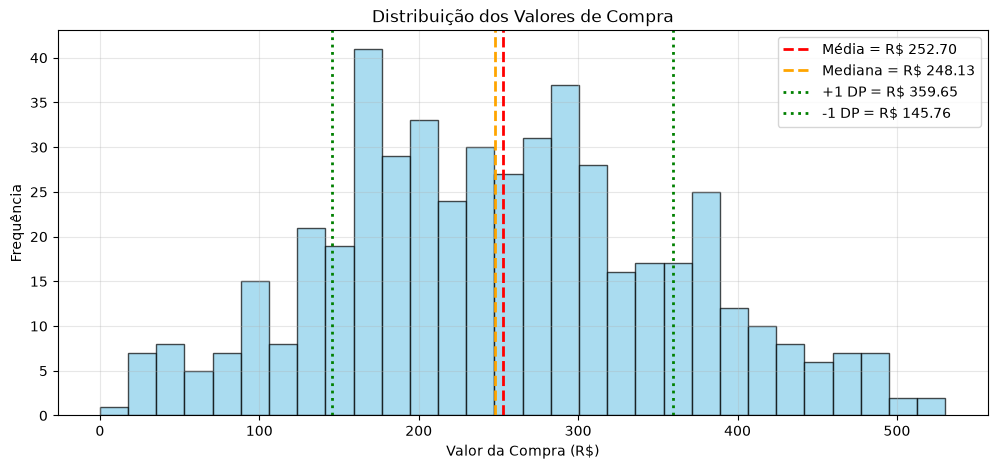

In [22]:
#--- GRÁFICO ---

plt.figure(figsize = (12, 5))
plt.hist(valor_col, bins = 30, color = 'skyblue', edgecolor = 'black', alpha = 0.7)
plt.axvline(media_valor, color = 'red', linestyle = '--', linewidth = 2, label = f'Média = R$ {media_valor:.2f}')
plt.axvline(mediana_valor, color = 'orange', linestyle = '--', linewidth = 2, label = f'Mediana = R$ {mediana_valor:.2f}')
plt.axvline(media_valor + std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'+1 DP = R$ {media_valor + std_valor:.2f}')
plt.axvline(media_valor - std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'-1 DP = R$ {media_valor - std_valor:.2f}')
plt.title('Distribuição dos Valores de Compra')
plt.xlabel('Valor da Compra (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


**Resultado da Análise Estatística Descritiva:**

O usuário acessa o site, em média, cerca de 26 vezes por mês, permanece em média 33 minutos navegando, adiciona aproximadamente 7 itens ao carrinho e realiza compras com <b>ticket médio de R$ 252,70</b>. 

O gasto típico fica próximo da <b>mediana de R$ 248,13</b>.

Mas há grande variação entre clientes, alguns <b>compram valores baixos a partir de R$ 23,42</b>. 

<b>Enquanto outros chegam a gastar até R$ 530,37</b>.

<hr style="height: 3px; background-color: #CBD5E0; border: none;">

<hr style="height: 3px; background-color: #CBD5E0; border: none;">

<h2><span style="font-family: 'Montserrat'; color: #000080; font-weight: bold; font-style: italic">MP3-Segmentação e Análise de Clientes - Parte 1/2</span></h2>

### <span style = "color:green; font-weight: bold"> Pergunta 2</span>

+ Quais são as características e comportamentos distintos dos nossos clientes de "Alto Valor"?
+ Eles visitam mais o site?
+ Passam mais tempo navegando?


In [23]:
# Filtro booleano para clientes com compras > R$250
clientes_alto_valor = dados_ecommerce [dados_ecommerce[:,3] > 250] #fatiando o array [linha,coluna]

## Estatísticas deste segmento
media_visitas_alto_valor = np.mean(clientes_alto_valor[:, 0]) # aqui temos o array clientes_alto_valor mas com menas linhas conforme o filtro acima
media_tempo_alto_valor = np.mean(clientes_alto_valor[:, 1])

#
print("\n--- ANÁLISE: CLIENTES DE ALTO VALOR (Compras > R$250) ---\n"
    f"\nNúmero de clientes de alto valor: {clientes_alto_valor.shape[0]}"
##
    f"\nMédia de visitas desses clientes: {media_visitas_alto_valor:.2f}"
    f"\nMédia de tempo no site desses clientes: {media_tempo_alto_valor:.2f} min")

--- ANÁLISE: CLIENTES DE ALTO VALOR (Compras > R$250) ---

Número de clientes de alto valor: 245
Média de visitas desses clientes: 33.29
Média de tempo no site desses clientes: 37.11 min

### <span style = "color:orange; font-weight: bold">Resposta da Pergunta 2:
Os clientes de alto valor <b>(aqueles que gastam mais de R$ 250)</b> visitam o site com maior frequência, em <b>média 33 vezes por mês</b>, e permanecem mais tempo navegando, cerca de <b>37 minutos por sessão</b>.<br>
##### <i><u>Esse comportamento indica um alto nível de engajamento, sugerindo que quanto mais esses usuários interagem com a plataforma, maior tende a ser o valor de suas compras.</i></u>


<hr style="height: 3px; background-color: #CBD5E0; border: none;">

<h2><span style="font-family: 'Montserrat'; color: #000080; font-weight: bold; font-style: italic">MP3-Segmentação e Análise de Clientes - Parte 2/2</span></h2>

### <span style = "color:green; font-weight: bold"> Pergunta 3</span>

##### <i>Os usuários que não realizam compras visitam o site em média 7 vezes e permanecem cerca de 15 minutos navegando, mas não finalizam nenhuma transação.</i><br>
Esse comportamento mostra que, mesmo com algum nível de interesse, eles acabam desistindo antes da compra, representando uma oportunidade para ações de remarketing, otimização do checkout e estratégias de incentivo, como descontos ou frete grátis, para aumentar a conversão.


In [24]:
# Filtro para visitantes que não compraram
visitantes_sem_compra = dados_ecommerce[dados_ecommerce[:, 3] == 0]

## Estatísticas deste segmento
media_tempo_sem_compra = np.mean(visitantes_sem_compra[:, 1]) 
media_visitas_sem_compra = np.mean(visitantes_sem_compra[:, 0])

#
print("\n-- ANÁLISE: VISITANTES QUE NÃO COMPRAM ---\n"
      f"\nNúmero de visitantes que não compraram: {visitantes_sem_compra.shape[0]}"
      
 ##     
      f"\nMédida de visitas desses visitantes: {media_visitas_sem_compra:.2f}"
      f"\nApesar de não comprarem, eles passam na média {media_tempo_sem_compra:.2f} min no site.")

-- ANÁLISE: VISITANTES QUE NÃO COMPRAM ---

Número de visitantes que não compraram: 1
Médida de visitas desses visitantes: 7.00
Apesar de não comprarem, eles passam na média 14.71 min no site.

#### <span style = "color:orange; font-weight: bold">Resposta da Pergunta 3:
<i><b>Os usuários que não realizam compras visitam o site em média 7 vezes e permanecem cerca de 15 minutos navegando, mas não finalizam nenhuma transação.</b></i><br>
Esse comportamento mostra que, mesmo com algum nível de interesse, eles acabam desistindo antes da compra, representando uma oportunidade para ações de remarketing, otimização do checkout e estratégias de incentivo, como descontos ou frete grátis, para aumentar a conversão.

<hr style="height: 3px; background-color: #CBD5E0; border: none;">

<h3><span style="font-family: 'Montserrat'; color: gray; font-weight: bold; font-style: italic">Análise de Correlação</span></h3>

#### Investigar a relação entre as diferentes variáveis. Uma matriz de correlação nos mostra como as variáveis se movem juntas. 
+ +1: Correlação positiva perfeita
+ -1: Correlação negativa perfeita
+ 0: Nenhuma correlação linear

### <span style = "color:green; font-weight: bold"> Pergunta 4</span>

<h5><i>Existe uma correlação estatisticamente relevante entre o tempo gasto no site, o número de itens no carrinho e o valor final da compra?</i></h5>

In [25]:
# A função np.corrcoef calcula a matriz de correlação
# rowvar=False indica que as colunas são as variáveis
matriz_correlacao = np.corrcoef(dados_ecommerce, rowvar = False)

print("\n--- MATRIZ DE CORRELAÇÃO ---\n"
      "\n[Visitas, Tempo, Itens, Valor]")
print(np.round(matriz_correlacao, 2))

--- MATRIZ DE CORRELAÇÃO ---

[Visitas, Tempo, Itens, Valor]

[[1.   0.83 0.65 0.65]
 [0.83 1.   0.6  0.59]
 [0.65 0.6  1.   1.  ]
 [0.65 0.59 1.   1.  ]]

<h4><span style = "color:gray; font-weight: bold; font-style: italic"> Colocar a matriz de correlação de forma gráfica.</span></h4>

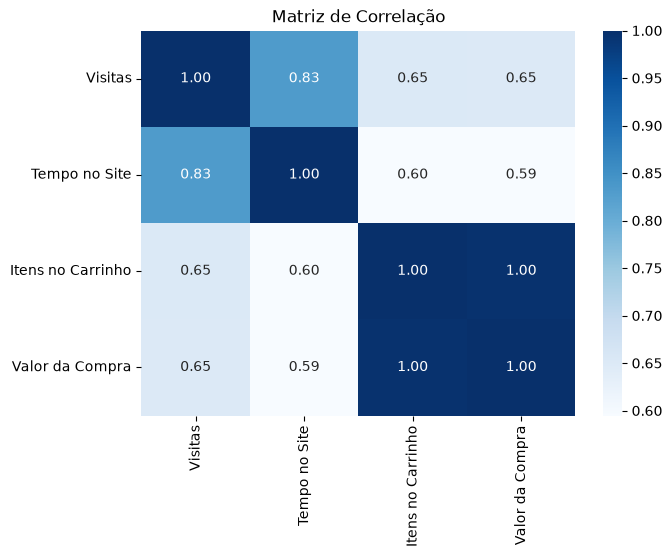

In [26]:
# Calcula a matriz de correlação
matriz_correlacao = np.corrcoef(dados_ecommerce, rowvar = False)

# Define os nomes das variáveis
nomes_variaveis = ["Visitas", "Tempo no Site", "Itens no Carrinho", "Valor da Compra"]

# Converte em DataFrame para exibir com rótulos
df_correlacao = pd.DataFrame(matriz_correlacao, 
                             index = nomes_variaveis, 
                             columns = nomes_variaveis)

# Matriz de correlação (mapa de calor)
plt.figure(figsize = (7, 5))
sns.heatmap(df_correlacao, annot = True, cmap = "Blues", fmt = ".2f")
plt.title("Matriz de Correlação")
plt.show()

#### <span style = "color:orange; font-weight: bold">Resposta da Pergunta 4:

#### Assim, a resposta para a pergunta seria:
Sim. Há uma correlação estatisticamente relevante: o tempo gasto no site se relaciona moderadamente tanto com o número de itens no carrinho quanto com o valor final da compra, e a quantidade de itens tem correlação praticamente perfeita com o valor final, indicando forte relação entre esses fatores.<br>
<i><b>Obs: Para confirmar a significância estatística, seria necessário calcular o p-valor dessas correlações.</b></i>


<h3><span style="font-family: 'Montserrat'; color: red; font-weight: bold; font-style: italic">Passo 6: Relatório Final, Conclusões e Insights a Partir dos Dados</span></h3>

A análise estatística dos dados de navegação e compras dos usuários do e-commerce permitiu compreender melhor o comportamento dos clientes e identificar padrões diretamente relacionados à geração de receita.

**1. Perfil Geral dos Usuários**

Os usuários acessam a plataforma em média 25,86 vezes por mês, permanecendo cerca de 32,78 minutos no site por sessão. Cada cliente adiciona, em média, 7,20 itens ao carrinho e realiza compras com ticket médio de R$ 252,70. 

A mediana do valor gasto é de R$ 248,13. 

Isso indica que metade dos clientes compra abaixo e metade acima desse valor. Observou-se uma dispersão considerável nos gastos (desvio padrão de R$ 106,94). As compras variam de 23,42 (mínimo) a 530,37 (máximo registrado).

Esses números mostram que existe um grupo expressivo de consumidores que gasta significativamente mais que a média, mas também há grande variação no comportamento de compra.

**2. Clientes de Alto Valor**

Ao analisar os clientes que gastam mais de R$ 250, identificou-se um total de 245 usuários, representando aproximadamente metade da base analisada. Este grupo se destaca por visitar mais vezes o site (33,29 visitas em média) e permanecer por mais tempo (37,11 minutos), comparado ao perfil geral.
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
Isso sugere que engajamento elevado, tanto em frequência de visitas quanto em tempo de navegação, está fortemente associado a compras de maior valor. Esses clientes podem ser considerados um segmento prioritário para ações de fidelização, programas de recompensa e campanhas personalizadas.

**3. Visitantes Que Não Compram**

Foi identificado apenas 1 usuário que navega sem realizar compras. Apesar de representar um caso isolado nesta base, ele visita em média 7 vezes e permanece 14,71 minutos no site. Esse comportamento, mesmo pouco expressivo aqui, ilustra a importância de monitorar usuários engajados que não convertem, pois podem representar oportunidades para campanhas de remarketing, melhorias no processo de checkout ou incentivos específicos para concluir a compra.

**4. Relações Entre Comportamentos e Receita**

A matriz de correlação revelou informações valiosas:

- Itens no Carrinho ↔ Valor da Compra = 1,00 → correlação positiva perfeita; cada item adicional impacta diretamente o valor gasto.

- Tempo no Site ↔ Itens no Carrinho = 0,60 → correlação moderada; usuários que permanecem mais tempo tendem a adicionar mais itens.

- Tempo no Site ↔ Valor da Compra = 0,59 → correlação moderada; quanto mais tempo no site, maior tende a ser a compra.

- Visitas ↔ Valor da Compra = 0,65 → correlação positiva; maior frequência de acessos também contribui para compras maiores.

Esses resultados confirmam que engajamento do usuário (tempo e visitas) influencia a construção do carrinho e, consequentemente, o valor final da compra. Embora seja necessário confirmar a significância estatística com testes adicionais (p-valor), a força das correlações já orienta decisões estratégicas.

<div class="alert alert-block alert-success">
<h4><span style="font-family: 'Montserrat'; color: brown; font-weight: bold; font-style: italic">5. Conclusões e Recomendações</span></h4>

<span style="font-family: 'Montserrat'; color: black; font-style: italic">
- Segmentação estratégica: os clientes de alto valor apresentam comportamento diferenciado, com maior frequência e tempo de navegação. Esse grupo deve ser alvo de campanhas personalizadas e programas de fidelidade para aumentar retenção e ticket médio.

- Incentivo à construção de carrinho: como a quantidade de itens é fator determinante no valor gasto, estratégias como recomendações personalizadas, descontos progressivos e combos podem elevar o ticket médio.

- Aproveitamento de visitantes engajados sem compra: embora pouco representativo aqui, vale investir em remarketing e otimização de UX para reduzir fricções no checkout e converter quem demonstra interesse.

- Base quantitativa para decisões: a análise estatística mostra que dados simples (visitas, tempo, itens) já oferecem insights poderosos para melhorar campanhas de marketing e decisões de produto, substituindo ações baseadas apenas em intuição.

Este Mini-Projeto, embora simples, demonstra como o NumPy, com poucas linhas de código, nos permite realizar uma análise estatística poderosa, desde a visão geral até a segmentação e correlação, transformando dados brutos em insights de negócio.</span>
</div>

### FIM 